# Figure 6: QC Covariate Impact Views

Builds two Figure 7 variants for `t1post_dwi_contrast` and `t1post_neighbor_corr` with:

- Panel A (top-left): winner-take-all IQM counts (excluding `no_quality` and `qc_prediction`)
- Panel B (top-right): cross-vendor age-effect correspondence change with QC covariate
- Panel C (bottom, full width): cold-scale heatmap of quality effect by metric and bundle



## Shared Setup

Libraries, config, plot style, figure directory, theme, and IQM/metric helpers.


In [150]:
# --- Libraries ---
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(forcats)
  library(fs)
  library(jsonlite)
  library(readr)
  library(stringr)
  library(purrr)
  library(scales)
  library(patchwork)
  library(grid)
})

# --- Config and project paths ---
config_candidates <- c(
  Sys.getenv("CONFIG_PATH", unset = ""),
  fs::path(".", "config.json"),
  fs::path("..", "config.json"),
  fs::path("..", "..", "config.json")
)
config_candidates <- normalizePath(unique(config_candidates[nzchar(config_candidates)]), winslash = "/", mustWork = FALSE)
config_path <- config_candidates[file.exists(config_candidates)][1]
if (is.na(config_path) || !nzchar(config_path)) {
  stop("Could not locate config.json. Set CONFIG_PATH or run from within the project tree.")
}
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)
plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)
plot_style <- get_plot_style(config)
plot_style$axis_line_width <- 0.35
plot_style$axis_tick_width <- 0.35
figure6_dir <- fs::path(project_root, "figures", "Figure6")
fs::dir_create(figure6_dir, recurse = TRUE)
font_family_use <- get_export_font_family()

# --- Panel theme helper (uses plot_style + font) ---
make_panel_theme <- function(legend_position = "none") {
  make_theme_pub(
    style = plot_style,
    legend_position = legend_position,
    axis_title_pt = 6,
    axis_text_pt = 5,
    plot_title_pt = 7,
    legend_title_pt = 5,
    legend_text_pt = 5,
    base_size_pt = 10
  ) +
    theme(text = element_text(family = font_family_use))
}
# save_plot_outputs from plot_style.R (out_dir = figure6_dir)

# --- Microstructural metrics and display labels ---
metrics_keep <- c("DKI_mkt", "NODDI_icvf", "MAPMRI_rtop", "GQI_fa", "GQI_md")
metric_labels <- c(
  "DKI_mkt" = "MKT",
  "NODDI_icvf" = "ICVF",
  "MAPMRI_rtop" = "RTOP",
  "GQI_fa" = "FA",
  "GQI_md" = "MD"
)
metric_order <- c("MKT", "ICVF", "RTOP", "FA", "MD")

# --- IQM (image quality metric) list and family/display helpers ---
iqm_metrics <- c(
  "raw_neighbor_corr", "raw_masked_neighbor_corr",
  "raw_dwi_contrast", "raw_num_bad_slices",
  "raw_coherence_index", "raw_incoherence_index",
  "t1_neighbor_corr", "t1_masked_neighbor_corr",
  "t1_dwi_contrast", "t1_num_bad_slices",
  "t1_coherence_index", "t1_incoherence_index",
  "t1post_neighbor_corr", "t1post_masked_neighbor_corr",
  "t1post_dwi_contrast", "t1post_num_bad_slices",
  "t1post_coherence_index", "t1post_incoherence_index",
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation", "t1_dice_distance",
  "CNR0_mean", "CNR1_mean", "CNR2_mean", "CNR3_mean", "CNR4_mean",
  "CNR0_median", "CNR1_median", "CNR2_median", "CNR3_median", "CNR4_median",
  "CNR0_standard_deviation", "CNR1_standard_deviation", "CNR2_standard_deviation",
  "CNR3_standard_deviation", "CNR4_standard_deviation"
)
motion_iqms <- c(
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation"
)
classify_family <- function(iqm) {
  if (iqm == "t1_dice_distance") return("Coregistration")
  if (iqm %in% motion_iqms) return("Motion")
  if (str_detect(iqm, "^CNR[0-4]_")) return("tSNR/CNR")
  if (str_detect(iqm, "neighbor_corr")) return("Neighbor Corr")
  if (str_detect(iqm, "dwi_contrast")) return("dMRI Contrast")
  if (str_detect(iqm, "num_bad_slices")) return("Bad Slices")
  if (str_detect(iqm, "coherence_index") || str_detect(iqm, "incoherence_index")) return("Coherence/Incoherence")
  "Other"
}

cnr_shell_label <- function(shell_id) {
  switch(
    shell_id,
    "0" = "tSNR (b=0)",
    "1" = "CNR (b=500)",
    "2" = "CNR (b=1000)",
    "3" = "CNR (b=2000)",
    "4" = "CNR (b=3000)",
    "CNR"
  )
}

format_iqm_label <- function(iqm) {
  if (iqm == "t1_dice_distance") return("dMRI-T1w Coregistration")
  if (iqm %in% c("mean_fd", "max_fd", "max_rotation", "max_translation", "max_rel_rotation", "max_rel_translation")) {
    name_map <- c(
      "mean_fd" = "Mean Framewise Displacement",
      "max_fd" = "Max Framewise Displacement",
      "max_rotation" = "Max Rotation",
      "max_translation" = "Max Translation",
      "max_rel_rotation" = "Max Relative Rotation (Derivative)",
      "max_rel_translation" = "Max Relative Translation (Derivative)"
    )
    return(unname(name_map[[iqm]]))
  }
  if (str_detect(iqm, "^CNR[0-4]_(mean|median|standard_deviation)$")) {
    shell_id <- str_match(iqm, "^CNR([0-4])_")[, 2]
    stat <- str_match(iqm, "^(?:CNR[0-4]_)(mean|median|standard_deviation)$")[, 2]
    stat_label <- recode(stat, mean = "Mean", median = "Median", standard_deviation = "SD")
    return(paste(cnr_shell_label(shell_id), stat_label))
  }
  prefix <- case_when(
    str_starts(iqm, "raw_") ~ "Raw",
    str_starts(iqm, "t1post_") ~ "Preprocessed (post-B1)",
    str_starts(iqm, "t1_") ~ "Preprocessed (pre-B1)",
    TRUE ~ ""
  )
  base <- iqm %>%
    str_remove("^raw_") %>%
    str_remove("^t1post_") %>%
    str_remove("^t1_")
  is_masked <- str_starts(base, "masked_")
  core_base <- if (is_masked) str_remove(base, "^masked_") else base
  base_label <- case_when(
    core_base == "neighbor_corr" ~ "Neighboring dMRI Correlation",
    core_base == "dwi_contrast" ~ "dMRI Contrast",
    core_base == "num_bad_slices" ~ "Number of Bad Slices",
    core_base == "coherence_index" ~ "Coherence Index",
    core_base == "incoherence_index" ~ "Incoherence Index",
    TRUE ~ core_base
  )
  qualifier_parts <- character(0)
  if (nzchar(prefix)) {
    q <- prefix %>%
      str_replace("Preprocessed \\(post-B1\\)", "Preprocessed, post-B1") %>%
      str_replace("Preprocessed \\(pre-B1\\)", "Preprocessed, pre-B1")
    qualifier_parts <- c(qualifier_parts, q)
  }
  if (is_masked) qualifier_parts <- c(qualifier_parts, "Masked")
  if (length(qualifier_parts) > 0) {
    paste0(base_label, " (", paste(qualifier_parts, collapse = ", "), ")")
  } else {
    base_label
  }
}
family_order <- c(
  "Neighbor Corr",
  "dMRI Contrast",
  "Coherence/Incoherence",
  "Bad Slices",
  "Motion",
  "tSNR/CNR",
  "Coregistration"
)
family_colors <- c(
  "Neighbor Corr" = "#1b9e77",
  "dMRI Contrast" = "#d95f02",
  "Coherence/Incoherence" = "#7570b3",
  "Bad Slices" = "#e7298a",
  "Motion" = "#66a61e",
  "tSNR/CNR" = "#e6ab02",
  "Coregistration" = "#a6761d"
)
# Build lookup: iqm -> pretty label and family for bar chart
iqm_dict <- tibble(iqm = iqm_metrics) %>%
  mutate(
    iqm_label = map_chr(iqm, format_iqm_label),
    family = factor(map_chr(iqm, classify_family), levels = family_order)
  )
# --- Load age–QC effect data (used for winner-take-all and per–QC heatmaps) ---
age_effect_file <- fs::path(project_root, "data", "age_quality_effects", "age_quality_effects_all_outputs.rds")
if (!file.exists(age_effect_file)) stop("Missing assembled age-effect file: ", age_effect_file)
df_age_all <- readRDS(age_effect_file)
required_age_cols <- c(
  "bundle", "bundle_category", "metric", "qc_metric", "source",
  "output_type", "qc_effect_size", "scanner_manufacturer", "age_effect_size"
)
if (!all(required_age_cols %in% names(df_age_all))) {
  stop("Assembled age-effect data missing required columns: ",
       paste(setdiff(required_age_cols, names(df_age_all)), collapse = ", "))
}
# Filter to harmonized non-vendorwise, five metrics, IQM covariates (exclude no_quality/qc_prediction)
df_qc_all <- df_age_all %>%
  filter(
    output_type == "non_vendorwise_pairwise",
    source == "harmonized",
    metric %in% metrics_keep,
    qc_metric %in% iqm_metrics,
    qc_metric != "qc_prediction",
    !is.na(bundle),
    !is.na(bundle_category),
    !is.na(qc_metric),
    !is.na(qc_effect_size)
  ) %>%
  transmute(
    # Keep bundle, metric, IQM, and QC effect for winner-take-all and heatmaps
    bundle = bundle,
    bundle_category = bundle_category,
    metric = metric,
    metric_label = unname(metric_labels[metric]),
    iqm = qc_metric,
    qc_effect_size = as.numeric(qc_effect_size)
  )
if (nrow(df_qc_all) == 0) {
  stop("No rows found for Figure 6 pooled quality-effects with requested IQMs.")
}


## Panel A: Winner-take-all bar chart

For each bundle–metric cell, which IQM had the largest (absolute) QC effect? Bar chart of win counts by IQM family.


In [151]:
# --- Winner-take-all: for each bundle–metric cell, which IQM had largest |QC effect|? ---
wta_counts <- df_qc_all %>%
  arrange(metric, bundle, iqm) %>%
  group_by(metric, bundle) %>%
  slice_max(order_by = qc_effect_size, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  count(iqm, name = "n_wins") %>%
  right_join(tibble(iqm = iqm_metrics), by = "iqm") %>%
  mutate(n_wins = replace_na(n_wins, 0L)) %>%
  left_join(iqm_dict, by = "iqm") %>%
  arrange(desc(n_wins), iqm)
readr::write_csv(wta_counts, fs::path(figure6_dir, "Figure6_winner_take_all_counts.csv"))
# Reshape for bar chart: n_wins per IQM family, ordered for display
wta_counts_plot <- wta_counts %>%
  filter(n_wins > 0) %>%
  mutate(iqm_label = forcats::fct_reorder(iqm_label, n_wins, .desc = TRUE)) %>%
  arrange(desc(n_wins))
# Bar chart: win count by IQM family (Panel A)
p_panel_a <- wta_counts_plot %>%
  ggplot(aes(x = forcats::fct_rev(iqm_label), y = n_wins, fill = family)) +
  geom_col(width = 0.84) +
  geom_text(aes(label = n_wins), hjust = -0.12, size = 1.7, family = font_family_use) +
  scale_fill_manual(values = family_colors, drop = TRUE) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
  scale_x_discrete(expand = expansion(add = c(0.10, 0.10))) +
  coord_flip(clip = "off") +
  labs(
    title = NULL,
    x = NULL,
    y = "Count of max quality effects",
    fill = "IQM Family"
  ) +
  make_panel_theme(legend_position = "none") +
  theme(
    panel.grid = element_blank(),
    plot.margin = margin(4, 4, 2, 4),
    axis.text.x = element_text(size = 5, color = "black"),
    axis.text.y = element_text(angle = 0, hjust = 1, vjust = 0.5, size = 5, color = "black"),
    legend.position = c(0.985, 0.35),
    legend.justification = c(1, 0),
    legend.direction = "vertical",
    legend.background = element_rect(fill = scales::alpha("white", 0.70), color = NA),
    legend.title = element_text(size = 6),
    legend.text = element_text(size = 6),
    legend.spacing.y = unit(0.4, "pt"),
    legend.key.height = unit(6, "pt"),
    legend.key.width = unit(6, "pt")
  )
pair_defs <- tibble::tribble(
  ~pair_label, ~vendor_x, ~vendor_y, ~line_type,
  "GE-Philips", "GE", "Philips", "dotdash",
  "Siemens-GE", "Siemens", "GE", "solid",
  "Siemens-Philips", "Siemens", "Philips", "dotted"
)
compute_pair_rho <- function(dat, vx, vy) {
  d <- dat %>% select(all_of(c(vx, vy))) %>% tidyr::drop_na()
  if (nrow(d) < 3) return(NA_real_)
  cor(d[[vx]], d[[vy]], method = "spearman")
}
prettify_bundle <- function(bundle_name) {
  bundle_name %>%
    str_replace("FrontoOccipital", "Fronto-Occipital") %>%
    str_replace("NonDecussating", "Non-Decussating") %>%
    str_replace("L$", " (L)") %>%
    str_replace("R$", " (R)") %>%
    str_replace_all("(?<=[a-z])(?=[A-Z])", " ")
}
category_order <- c(
  "Association",
  "Projection (Basal Ganglia)",
  "Projection (Brainstem)",
  "Cerebellum",
  "Corpus Callosum"
)
qc_targets <- c("t1post_dwi_contrast")
qc_target_titles <- c(
  "t1post_dwi_contrast" = "Preprocessed dMRI Contrast",
  "t1post_neighbor_corr" = "Preprocessed Neighboring dMRI Correlation"
)
# Combined figure width 180 mm; heatmap shorter so grid aspect matches Figure 3/4 (wider, less tall)
figure_width_mm <- 180
figure_width_in <- figure_width_mm / 25.4
panel_width_mm <- 88
panel_height_in <- (panel_width_mm / 25.4) * 0.96
heatmap_height_scale <- 0.47
heat_height_in <- panel_height_in * heatmap_height_scale
top_row_height_in <- 3.35
figure_height_in <- top_row_height_in + heat_height_in
save_plot_outputs(p_panel_a, "Figure6_panel_a_winner_take_all", figure6_dir, figure_width_in * 0.56, top_row_height_in)


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/Figure6_panel_a_winner_take_all.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/Figure6_panel_a_winner_take_all.png



## Panels B & C (per QC target): QC scatter and quality heatmap

For each QC covariate: Panel B shows QC vs highlighted bundle–metric outcome (GAMM-derived curve); Panel C shows heatmap of QC effect sizes. Combined layout saved per target.


[INFO] Figure6 max QC effect for t1post_dwi_contrast: metric=GQI_fa | bundle=FornixR | category=ProjectionBasalGanglia | qc_effect_size=0.1287

[INFO] Loaded panel B cache: /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/Figure6_t1post_dwi_contrast_panel_b_qc_scatter_cache.rds

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/Figure6_t1post_dwi_contrast_panel_b_qc_scatter.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/Figure6_t1post_dwi_contrast_panel_b_qc_scatter.png

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/Figure6_t1post_dwi_contrast_panel_c_quality_heatmap.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/Figure6_t1post_dwi_contrast_panel_c_quality_heatmap.png

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/Figure6_t1pos

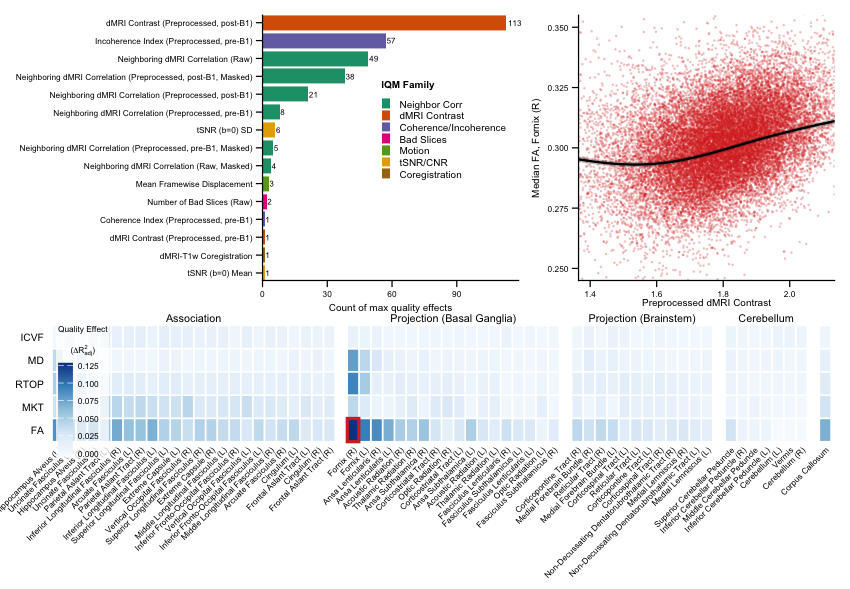

In [152]:
# For each QC covariate: build heatmap data, identify max-effect cell, Panel B (GAMM scatter), Panel C (heatmap), combine and save
for (qc_target in qc_targets) {
  qc_title <- unname(qc_target_titles[[qc_target]])
  # Filter to this QC; order bundles; get bundle–metric cell with largest QC effect (for Panel B/C focus)
  df_heat <- df_qc_all %>%
    filter(iqm == qc_target) %>%
    mutate(
      metric_label = dplyr::coalesce(unname(metric_labels[as.character(metric)]), as.character(metric)),
      bundle_category_raw = bundle_category,
      bundle_category_pretty = case_when(
        bundle_category == "ProjectionBasalGanglia" ~ "Projection (Basal Ganglia)",
        bundle_category == "ProjectionBrainstem" ~ "Projection (Brainstem)",
        bundle_category == "Commissure" ~ "Corpus Callosum",
        TRUE ~ bundle_category
      ),
      bundle_clean = dplyr::coalesce(prettify_bundle(as.character(bundle)), as.character(bundle))
    )
  if (nrow(df_heat) == 0) {
    stop("No pooled heatmap rows for qc metric: ", qc_target)
  }
  metric_order_heat <- df_heat %>%
    group_by(metric_label) %>%
    summarise(mean_effect = mean(qc_effect_size, na.rm = TRUE), .groups = "drop") %>%
    arrange(desc(mean_effect)) %>%
    pull(metric_label)
  df_heat <- df_heat %>%
    mutate(
      metric_label = factor(metric_label, levels = metric_order_heat),
      bundle_category_pretty = factor(bundle_category_pretty, levels = category_order)
    )
  bundle_df <- df_heat %>%
    group_by(bundle_category_pretty, bundle_category_raw, bundle_clean, bundle) %>%
    summarise(mean_effect = mean(qc_effect_size, na.rm = TRUE), .groups = "drop") %>%
    arrange(bundle_category_pretty, desc(mean_effect), bundle_clean)
  bundle_levels <- c()
  for (cat in category_order) {
    cat_bundles <- bundle_df %>% filter(bundle_category_pretty == cat) %>% pull(bundle_clean)
    if (length(cat_bundles) > 0) {
      bundle_levels <- c(bundle_levels, cat_bundles, paste0("spacer_", cat))
    }
  }
  bundle_levels <- bundle_levels[!grepl("^spacer_Corpus Callosum$", bundle_levels)]
  if (length(bundle_levels) == 0) {
    stop("No bundle levels for qc metric: ", qc_target)
  }
  df_heat <- df_heat %>%
    mutate(bundle_clean = factor(bundle_clean, levels = bundle_levels))
  highlight_cell <- df_heat %>%
    arrange(desc(qc_effect_size)) %>%
    slice(1) %>%
    select(
      bundle_clean, metric_label, metric, bundle,
      bundle_category_raw, bundle_category_pretty, qc_effect_size
    )
  if (nrow(highlight_cell) != 1) {
    stop("Could not identify a unique max quality-effect heatmap cell for ", qc_target)
  }
  highlight_metric <- as.character(highlight_cell$metric[[1]])
  highlight_metric_label <- as.character(highlight_cell$metric_label[[1]])
  highlight_bundle <- as.character(highlight_cell$bundle[[1]])
  highlight_bundle_category_raw <- as.character(highlight_cell$bundle_category_raw[[1]])
  highlight_bundle_clean <- as.character(highlight_cell$bundle_clean[[1]])
  highlight_qc_effect <- as.numeric(highlight_cell$qc_effect_size[[1]])
  message(
    "[INFO] Figure6 max QC effect for ", qc_target,
    ": metric=", highlight_metric,
    " | bundle=", highlight_bundle,
    " | category=", highlight_bundle_category_raw,
    " | qc_effect_size=", signif(highlight_qc_effect, 4)
  )
  # Panel B: QC-vs-bundle scatter from GAMM fit (cached)
  harm_path <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
  if (!file_exists(harm_path)) stop("Missing harmonized parquet: ", harm_path)
  harm_cols <- arrow::open_dataset(harm_path, format = "parquet")$schema$names
  bundle_col <- paste0(
    "bundle_",
    highlight_bundle_category_raw,
    "_",
    highlight_bundle,
    "_",
    highlight_metric,
    "_median"
  )
  if (!bundle_col %in% harm_cols) {
    fallback_hits <- harm_cols[str_detect(harm_cols, fixed(paste0("_", highlight_bundle, "_", highlight_metric, "_median")))]
    if (length(fallback_hits) == 0) {
      stop("Could not locate panel B bundle column: ", bundle_col)
    }
    bundle_col <- fallback_hits[1]
    message("[WARN] Using fallback panel B bundle column: ", bundle_col)
  }
  panel_b_cache_file <- fs::path(figure6_dir, paste0("Figure6_", qc_target, "_panel_b_qc_scatter_cache.rds"))
  panel_b_cache_key <- list(
    qc_metric = qc_target,
    metric = highlight_metric,
    bundle = highlight_bundle,
    bundle_category = highlight_bundle_category_raw,
    bundle_col = bundle_col,
    harmonized_mtime = as.character(file.info(harm_path)$mtime)
  )
  df_panel_b <- NULL
  curve_df <- NULL
  cache_used <- FALSE
  if (file_exists(panel_b_cache_file)) {
    cache_obj <- tryCatch(readRDS(panel_b_cache_file), error = function(e) NULL)
    if (
      is.list(cache_obj) &&
      identical(cache_obj$key, panel_b_cache_key) &&
      is.data.frame(cache_obj$df_panel_b) &&
      is.data.frame(cache_obj$curve_df)
    ) {
      df_panel_b <- cache_obj$df_panel_b
      curve_df <- cache_obj$curve_df
      cache_used <- TRUE
      message("[INFO] Loaded panel B cache: ", panel_b_cache_file)
    } else {
      message("[INFO] Panel B cache exists but key/data mismatch; recomputing.")
    }
  }
  fit_gamm_with_fallback <- function(formula, data) {
    m <- tryCatch(
      gamm4::gamm4(formula = formula, random = ~(1 + age | subject_id), data = data),
      error = function(e) NULL
    )
    if (is.null(m)) {
      m <- tryCatch(
        gamm4::gamm4(formula = formula, random = ~(1 | subject_id), data = data),
        error = function(e) NULL
      )
    }
    m
  }
  if (!cache_used) {
    df_panel_b <- arrow::read_parquet(
      harm_path,
      col_select = all_of(c("subject_id", "site", "sex", "age", qc_target, bundle_col))
    ) %>%
      as_tibble() %>%
      transmute(
        subject_id = factor(subject_id),
        site = factor(site),
        sex = factor(sex),
        age = as.numeric(age),
        qc_var = as.numeric(.data[[qc_target]]),
        value = as.numeric(.data[[bundle_col]])
      ) %>%
      filter(!is.na(value), !is.na(qc_var), !is.na(age), !is.na(site), !is.na(sex), !is.na(subject_id))
    if (nrow(df_panel_b) < 100) {
      stop("Insufficient rows for Figure6 panel B GAMM (n < 100) for qc=", qc_target)
    }
    if (!requireNamespace("gamm4", quietly = TRUE)) {
      stop("Figure6 panel B requires package 'gamm4'.")
    }
    full_mod <- fit_gamm_with_fallback(
      value ~ s(age, k = 4) + sex + s(qc_var, k = 4) + site,
      data = df_panel_b
    )
    if (is.null(full_mod)) {
      stop("Figure6 panel B GAMM fit failed for qc=", qc_target)
    }
    qc_grid <- seq(
      quantile(df_panel_b$qc_var, 0.01, na.rm = TRUE),
      quantile(df_panel_b$qc_var, 0.99, na.rm = TRUE),
      length.out = 220
    )
    ref_age <- median(df_panel_b$age, na.rm = TRUE)
    ref_sex <- names(sort(table(df_panel_b$sex), decreasing = TRUE))[1]
    ref_site <- names(sort(table(df_panel_b$site), decreasing = TRUE))[1]
    pred_grid <- tibble(
      qc_var = qc_grid,
      age = ref_age,
      sex = factor(ref_sex, levels = levels(df_panel_b$sex)),
      site = factor(ref_site, levels = levels(df_panel_b$site))
    )
    pred <- predict(full_mod$gam, newdata = pred_grid, se.fit = TRUE)
    curve_df <- pred_grid %>%
      transmute(
        qc_var = qc_var,
        fit = as.numeric(pred$fit),
        lower = fit - 1.96 * as.numeric(pred$se.fit),
        upper = fit + 1.96 * as.numeric(pred$se.fit)
      )
    saveRDS(
      list(
        key = panel_b_cache_key,
        df_panel_b = df_panel_b,
        curve_df = curve_df
      ),
      panel_b_cache_file
    )
    message("[INFO] Saved panel B cache: ", panel_b_cache_file)
  }
  panel_b_ylabel <- paste0("Median ", highlight_metric_label, ", ", highlight_bundle_clean)
  highlight_red <- "#D73027"
  is_right_fornix_fa <- (highlight_metric == "GQI_fa" && (highlight_bundle == "FornixR" | stringr::str_detect(highlight_bundle, "[Rr]ight.*[Ff]ornix|[Ff]ornix.*[Rr]")))
  if (is_right_fornix_fa) {
    p_panel_b <- ggplot(df_panel_b, aes(x = qc_var, y = value)) +
      geom_point(color = highlight_red, alpha = 0.28, size = 0.7, stroke = 0) +
      geom_ribbon(
        data = curve_df,
        aes(x = qc_var, ymin = lower, ymax = upper),
        inherit.aes = FALSE,
        fill = "black",
        alpha = 0.25
      ) +
      geom_line(
        data = curve_df,
        aes(x = qc_var, y = fit),
        inherit.aes = FALSE,
        color = "black",
        linewidth = 0.66
      ) +
      labs(title = NULL, x = qc_title, y = panel_b_ylabel) +
      coord_cartesian(xlim = c(1.4, 2.1), ylim = c(0.25, 0.35), clip = "on") +
      make_panel_theme(legend_position = "none") +
      theme(
        panel.grid = element_blank(),
        plot.margin = margin(2, 4, 0, 4),
        axis.title.x = element_text(margin = margin(t = 0))
      )
  } else {
    panel_b_density_layer <- if (requireNamespace("hexbin", quietly = TRUE)) {
      geom_hex(aes(fill = after_stat(count)), bins = 42, color = NA, alpha = 0.96)
    } else {
      message("[WARN] Package 'hexbin' not found; using square bins for panel B.")
      geom_bin_2d(aes(fill = after_stat(count)), bins = 42, color = NA, alpha = 0.96)
    }
    p_panel_b <- ggplot(df_panel_b, aes(x = qc_var, y = value)) +
      panel_b_density_layer +
      scale_fill_gradientn(
        colours = c("#f7fbff", "#deebf7", "#9ecae1", "#4292c6", "#08519c"),
        name = "Count",
        guide = guide_colorbar(barheight = unit(28, "pt"), barwidth = unit(6, "pt"))
      ) +
      geom_line(data = curve_df, aes(x = qc_var, y = fit), inherit.aes = FALSE, color = "#d62728", linewidth = 0.66) +
      labs(title = NULL, x = qc_title, y = panel_b_ylabel) +
      coord_cartesian(ylim = c(min(df_panel_b$value, na.rm = TRUE), 0.4), clip = "off") +
      make_panel_theme(legend_position = "none") +
      theme(
        panel.grid = element_blank(),
        plot.margin = margin(2, 4, 0, 4),
        axis.title.x = element_text(margin = margin(t = 0)),
        legend.position = c(0.985, 0.05),
        legend.justification = c(1, 0),
        legend.background = element_rect(fill = scales::alpha("white", 0.75), color = NA),
        legend.title = element_text(size = 6),
        legend.text = element_text(size = 6),
        legend.key.height = unit(9, "pt"),
        legend.key.width = unit(6, "pt")
      )
  }
  # Panel C: heatmap with category spacers/labels and red max-effect rectangle
  spacer_df <- expand.grid(
    bundle_clean = bundle_levels[grepl("^spacer_", bundle_levels)],
    metric_label = metric_order_heat,
    KEEP.OUT.ATTRS = FALSE,
    stringsAsFactors = FALSE
  ) %>%
    mutate(
      qc_effect_size = NA_real_,
      bundle_clean = factor(bundle_clean, levels = bundle_levels),
      metric_label = factor(metric_label, levels = metric_order_heat)
    )
  df_heat_plot <- bind_rows(
    df_heat %>% select(bundle_clean, metric_label, qc_effect_size),
    spacer_df
  )
  x_labels <- levels(df_heat_plot$bundle_clean)
  x_labels[grepl("^spacer_", x_labels)] <- ""
  bundle_index_df <- tibble(bundle_clean = bundle_levels, index = seq_along(bundle_levels))
  cat_positions <- bundle_df %>%
    group_by(bundle_category_pretty) %>%
    summarise(
      xmin = min(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
      xmax = max(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
      xmid = mean(c(xmin, xmax)),
      .groups = "drop"
    ) %>%
    filter(bundle_category_pretty != "Corpus Callosum")
  heatmap_export_width_in <- figure_width_in
  heatmap_final_width_in <- figure_width_in
  heatmap_tile_height <- 1.00
  p_panel_c <- ggplot(df_heat_plot, aes(x = bundle_clean, y = metric_label, fill = qc_effect_size)) +
    geom_tile(color = "white", linewidth = 0.45, height = heatmap_tile_height) +
    geom_tile(
      data = highlight_cell,
      aes(x = bundle_clean, y = metric_label),
      fill = NA,
      color = "#D73027",
      linewidth = 0.9,
      width = 0.98,
      height = heatmap_tile_height,
      inherit.aes = FALSE
    ) +
    scale_fill_gradientn(
      colours = c("#f7fbff", "#deebf7", "#9ecae1", "#4292c6", "#084594"),
      name = expression(atop("Quality Effect", "(" * Delta * R[adj]^2 * ")")),
      na.value = "white"
    ) +
    guides(fill = guide_colorbar(
      barheight = unit(length(metric_order_heat) * heatmap_tile_height * 0.78, "lines"),
      barwidth = unit(0.62, "lines")
    )) +
    scale_x_discrete(labels = x_labels, expand = expansion(add = 0.8)) +
    scale_y_discrete(expand = expansion(mult = c(0, 0))) +
    coord_cartesian(clip = "off") +
    labs(title = NULL, x = NULL, y = NULL) +
    theme_minimal(
      base_family = font_family_use,
      base_size = pt_for_export(6, heatmap_export_width_in, heatmap_final_width_in)
    ) +
    theme(
      panel.grid = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in), color = "black"),
      axis.text.y = element_text(size = pt_for_export(6.2, heatmap_export_width_in, heatmap_final_width_in), color = "black"),
      axis.ticks = element_blank(),
      plot.title = element_blank(),
      plot.margin = margin(44, 14, 6, 58),
      legend.title = element_text(size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in), color = "black"),
      legend.text = element_text(size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in), color = "black"),
      legend.position = c(0.01, 0.97),
      legend.justification = c(0, 1),
      legend.direction = "vertical",
      legend.margin = margin(1, 1, 1, 1),
      legend.background = element_rect(fill = scales::alpha("white", 0.76), color = NA),
      legend.box.background = element_blank(),
      panel.background = element_rect(fill = plot_style$panel_background_fill, color = NA),
      plot.background = element_rect(fill = plot_style$plot_background_fill, color = NA),
      panel.border = element_blank()
    )
  y_top <- length(metric_order_heat) + 0.82
  for (i in seq_len(nrow(cat_positions))) {
    p_panel_c <- p_panel_c + annotate(
      "text",
      x = cat_positions$xmid[i],
      y = y_top,
      label = as.character(cat_positions$bundle_category_pretty[i]),
      family = font_family_use,
      size = pt_for_export(6.5, heatmap_export_width_in, heatmap_final_width_in) / .pt,
      color = "black"
    )
  }
  top_row <- p_panel_a | p_panel_b
  top_row <- top_row + patchwork::plot_layout(widths = c(1, 1))
  # Assemble: Panel A (from above) + Panel B + Panel C; then save individual panels and combined
  combined <- top_row / patchwork::free(p_panel_c, side = "l") +
    patchwork::plot_layout(heights = c(top_row_height_in, heat_height_in)) +
    theme(plot.margin = margin(0, 0, 0, 0))
  options(repr.plot.width = figure_width_in, repr.plot.height = figure_height_in, repr.plot.res = 120)
  print(combined)
  stub <- paste0("Figure6_", qc_target)
  save_plot_outputs(p_panel_b, paste0(stub, "_panel_b_qc_scatter"), figure6_dir, figure_width_in * 0.44, top_row_height_in)
  save_plot_outputs(p_panel_c, paste0(stub, "_panel_c_quality_heatmap"), figure6_dir, figure_width_in, heat_height_in)
  save_plot_outputs(combined, paste0(stub, "_combined"), figure6_dir, figure_width_in, figure_height_in)
}
message("[DONE] Figure 6 variants generated for: ", paste(qc_targets, collapse = ", "))
